# 03 — Convergence Diagnostics & Posterior Inference

Verify the sampler converged, inspect posterior coefficients, and extract per-customer uncertainty. This is the step most portfolios skip.

In [1]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
import os

features = [
    "tenure", "MonthlyCharges", "TotalCharges",
    "Contract_Month_to_month", "Contract_Two_year",
    "InternetService_Fiber_optic", "SeniorCitizen",
]

trace_path = "../outputs/trace.nc"
if not os.path.exists(trace_path):
    raise FileNotFoundError(
        "trace.nc not found. Run 02_bayesian_model.ipynb first to generate it."
    )

trace = az.from_netcdf(trace_path)
print("Trace loaded successfully.")

Trace loaded successfully.


## 1. Numerical diagnostics

- **R-hat < 1.01**: both chains converged to the same distribution
- **ESS > 400**: enough independent samples to trust credible intervals
- **Divergences = 0**: NUTS explored the posterior without getting stuck

In [2]:
summary = az.summary(trace, var_names=["alpha", "betas"])
summary.index = ["alpha"] + features
print(f"R-hat max    : {summary.r_hat.max():.4f}  (target < 1.01)")
print(f"ESS bulk min : {summary.ess_bulk.min():.0f}   (target > 400)")
print(f"Divergences  : {int(trace.sample_stats.diverging.values.sum())}        (target = 0)")
summary[["mean", "sd", "r_hat", "ess_bulk", "ess_tail"]]

R-hat max    : 1.0000  (target < 1.01)
ESS bulk min : 4513   (target > 400)
Divergences  : 0        (target = 0)


,mean,sd,r_hat,ess_bulk,ess_tail
alpha,-1.659,0.052,1.0,5602.0,5804.0
tenure,-1.245,0.141,1.0,4673.0,4820.0
MonthlyCharges,0.384,0.076,1.0,5454.0,5310.0
TotalCharges,0.428,0.146,1.0,4513.0,4772.0
Contract_Month_to_month,0.458,0.052,1.0,7230.0,5690.0
Contract_Two_year,-0.383,0.073,1.0,7101.0,5612.0
InternetService_Fiber_optic,0.354,0.058,1.0,6329.0,5537.0
SeniorCitizen,0.153,0.029,1.0,7087.0,5199.0


## 2. Trace plots

Both chains should overlap and be stationary — no trends, no drift.

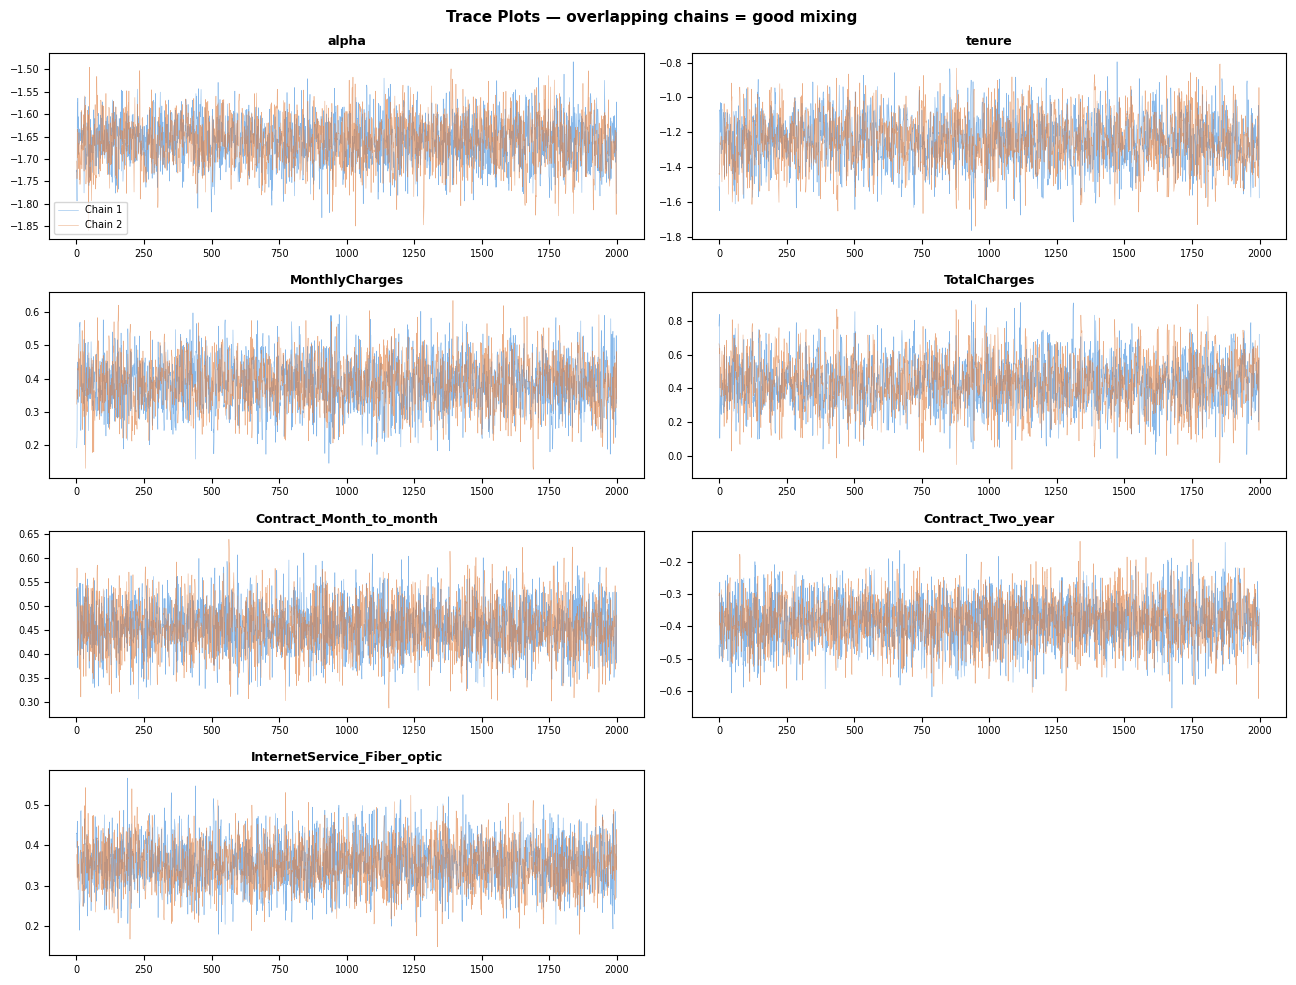

In [3]:
betas_s = trace.posterior["betas"].values   # (chains, draws, 7)
alpha_s = trace.posterior["alpha"].values   # (chains, draws)
all_s   = [alpha_s] + [betas_s[:, :, i] for i in range(7)]
params  = ["alpha"] + features
colors  = ["#378ADD", "#E07B39"]

fig, axes = plt.subplots(4, 2, figsize=(13, 10))
axes = axes.flatten()
for idx, (ax, name, samples) in enumerate(zip(axes, params, all_s)):
    for c, (chain, col) in enumerate(zip(samples, colors)):
        ax.plot(chain, alpha=0.6, color=col, linewidth=0.4, label=f"Chain {c+1}")
    ax.set_title(name, fontsize=9, fontweight="bold")
    ax.tick_params(labelsize=7)
    if idx == 0:
        ax.legend(fontsize=7)
axes[-1].set_visible(False)
fig.suptitle("Trace Plots — overlapping chains = good mixing", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Posterior coefficients (forest plot)

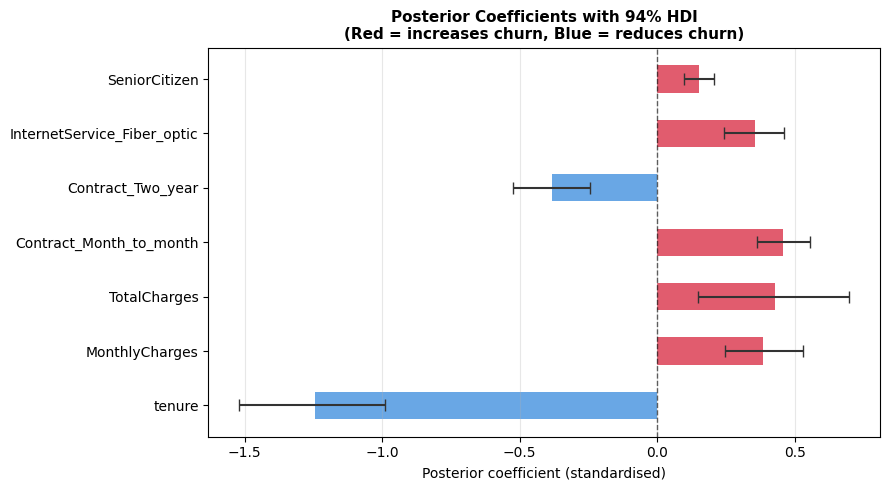

In [4]:
means = summary.loc[features, "mean"].values
lo    = summary.loc[features, "hdi_3%"].values
hi    = summary.loc[features, "hdi_97%"].values
colors_bar = ["#D7263D" if m > 0 else "#378ADD" for m in means]
y_pos = np.arange(len(features))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(y_pos, means, xerr=[means - lo, hi - means],
        color=colors_bar, alpha=0.75,
        error_kw=dict(ecolor="#333", capsize=4, lw=1.5), height=0.5)
ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(features, fontsize=10)
ax.set_xlabel("Posterior coefficient (standardised)", fontsize=10)
ax.set_title("Posterior Coefficients with 94% HDI\n(Red = increases churn, Blue = reduces churn)",
             fontsize=11, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Per-customer uncertainty

The key Bayesian output: not just a score, but a distribution over that score per customer.

In [6]:
# Recompute p from posterior samples — works even without pm.Deterministic("p")
# Needed because we removed p from the model to fix GPU OOM

# Load data to get X (needed to compute p)
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df["Churn"] = (df["Churn"] == "Yes").astype(int)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()
df = pd.get_dummies(df, columns=["Contract", "InternetService"], drop_first=False)
df.columns = df.columns.str.replace(" ", "_").str.replace("-", "_")

features = [
    "tenure", "MonthlyCharges", "TotalCharges",
    "Contract_Month_to_month", "Contract_Two_year",
    "InternetService_Fiber_optic", "SeniorCitizen",
]
X = StandardScaler().fit_transform(df[features])

# Reconstruct p from posterior alpha and betas
betas_flat = trace.posterior["betas"].values.reshape(-1, 7)  # (4000, 7)
alpha_flat  = trace.posterior["alpha"].values.reshape(-1)    # (4000,)

logit_samples = alpha_flat[:, None] + betas_flat @ X.T       # (4000, N)
p_samples     = 1 / (1 + np.exp(-logit_samples))             # (4000, N)

mean_churn  = p_samples.mean(axis=0)
lo_c        = np.percentile(p_samples, 3,  axis=0)
hi_c        = np.percentile(p_samples, 97, axis=0)
uncertainty = hi_c - lo_c
thresh_u    = np.percentile(uncertainty, 80)

print(f"Avg churn probability  : {mean_churn.mean():.3f}")
print(f"Avg uncertainty width  : {uncertainty.mean():.4f}")
print(f"High risk (prob > 0.5) : {(mean_churn > 0.5).sum()}")
print(f"High risk + uncertain  : {((mean_churn > 0.5) & (uncertainty > thresh_u)).sum()}")

Avg churn probability  : 0.266
Avg uncertainty width  : 0.0449
High risk (prob > 0.5) : 1444
High risk + uncertain  : 354


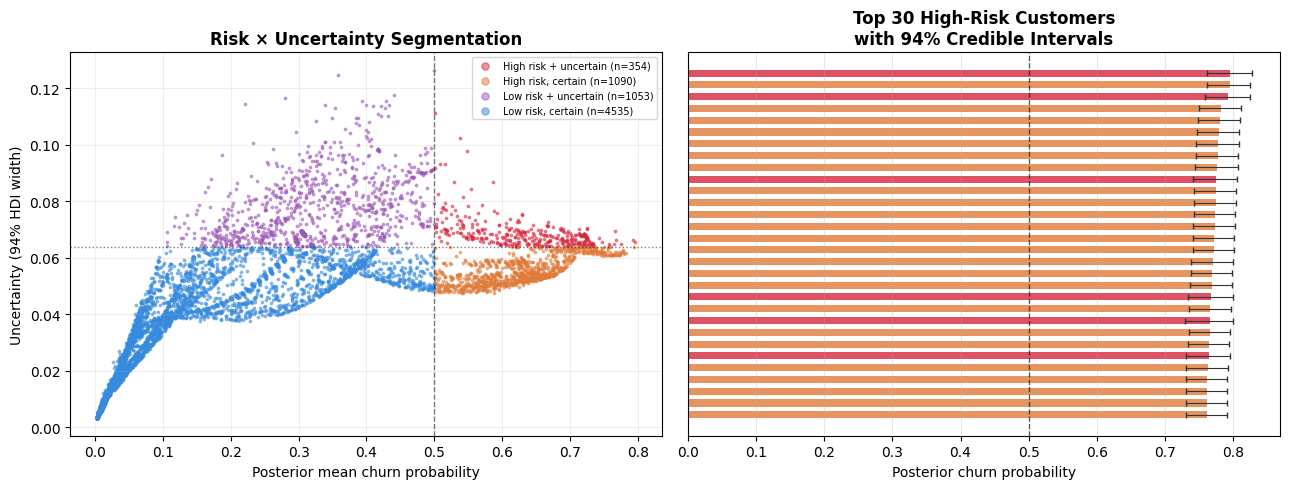

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: churn probability vs uncertainty
categories = np.where(
    (mean_churn > 0.5) & (uncertainty > thresh_u), "High risk + uncertain",
    np.where(mean_churn > 0.5, "High risk, certain",
    np.where(uncertainty > thresh_u, "Low risk + uncertain", "Low risk, certain")))

cmap = {
    "High risk + uncertain": "#D7263D",
    "High risk, certain":    "#E07B39",
    "Low risk + uncertain":  "#9B59B6",
    "Low risk, certain":     "#378ADD",
}
ax = axes[0]
for label, col in cmap.items():
    mask = categories == label
    ax.scatter(mean_churn[mask], uncertainty[mask],
               c=col, s=3, alpha=0.5, label=f"{label} (n={mask.sum()})")
ax.axvline(0.5, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax.axhline(thresh_u, color="black", linewidth=1, linestyle=":", alpha=0.5)
ax.set_xlabel("Posterior mean churn probability")
ax.set_ylabel("Uncertainty (94% HDI width)")
ax.set_title("Risk × Uncertainty Segmentation", fontweight="bold")
ax.legend(fontsize=7, markerscale=3)
ax.grid(alpha=0.2)

# Top 30 high-risk with credible intervals
high_idx = np.where(mean_churn > 0.5)[0]
high_idx = high_idx[np.argsort(mean_churn[high_idx])[-30:]]
y_pos = np.arange(len(high_idx))
bar_col = ["#D7263D" if uncertainty[i] > thresh_u else "#E07B39" for i in high_idx]

ax2 = axes[1]
ax2.barh(y_pos, mean_churn[high_idx], color=bar_col, alpha=0.8, height=0.6)
ax2.errorbar(mean_churn[high_idx], y_pos,
             xerr=[mean_churn[high_idx]-lo_c[high_idx], hi_c[high_idx]-mean_churn[high_idx]],
             fmt="none", color="#333", capsize=2, linewidth=0.8)
ax2.axvline(0.5, color="black", linewidth=1, linestyle="--", alpha=0.6)
ax2.set_xlabel("Posterior churn probability")
ax2.set_title("Top 30 High-Risk Customers\nwith 94% Credible Intervals", fontweight="bold")
ax2.set_yticks([])
ax2.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Save customer-level results

In [8]:
df_out = pd.DataFrame({
    "mean_churn_prob": mean_churn.round(4),
    "hdi_3pct":        lo_c.round(4),
    "hdi_97pct":       hi_c.round(4),
    "uncertainty":     uncertainty.round(4),
    "high_risk":       (mean_churn > 0.5).astype(int),
    "high_uncertainty":(uncertainty > thresh_u).astype(int),
})
df_out["priority_for_review"] = (
    (df_out.high_risk == 1) & (df_out.high_uncertainty == 1)
).astype(int)

df_out.to_csv("../outputs/customer_uncertainty.csv", index=False)
print(f"Saved. Customers flagged for review: {df_out.priority_for_review.sum()}")
df_out.head()

Saved. Customers flagged for review: 354


,mean_churn_prob,hdi_3pct,hdi_97pct,uncertainty,high_risk,high_uncertainty,priority_for_review
0,0.3342,0.3039,0.3643,0.0603,0,0,0
1,0.0703,0.0578,0.0839,0.0260,0,0,0
2,0.3968,0.3675,0.4263,0.0589,0,0,0
3,0.0345,0.0264,0.0437,0.0173,0,0,0
4,0.6264,0.5979,0.6556,0.0577,1,0,0
